<div style="text-align: right">Author: Yuktha Bhadane (yb294@cornell.edu)</div>

### Energy, Capacity, Emissions Mix Visualization by Country/Group
This notebook creates visualizations of energy mix (capacity, generation, and emissions) for groups (global, developing countries, developed countries) and the set of eight developing countries using donut charts.

0. Set Up

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

1. Helper Functions

In [21]:
def create_visualization_block(df, title, mask, is_group=False):
    """
    Create a set of three donut charts showing capacity, generation, and emissions.
    """
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    if is_group:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=1.15)
    else:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=1.15)
    
    subsectors = ['Coal', 'Gas', 'Oil', 'Solar', 'Wind', 'Hydropower', 
                 'Geothermal', 'Nuclear', 'Bioenergy']
    metrics = ['capacity', 'activity', 'annualco2tyear']
    titles = ['Installed\nCapacity', 'Electricity\nGenerated', 'Emissions']
    
    for ax, metric, title_text in zip(axes, metrics, titles):
        data = df[mask].groupby('subsector')[metric].sum()
        data = data.reindex(subsectors).fillna(0)
        total_value = data.sum()
        
        if total_value > 0:
            wedges, _ = ax.pie(data, wedgeprops=dict(width=0.4), startangle=90)
            ax.text(0, 0, format_value(total_value, metric),
                   ha='center', va='center', fontsize=10)
        
        ax.set_title(title_text, pad=0, fontsize=10)
        ax.axis('equal')
    
    # Create output directory and save figure
    output_dir = Path("energy_mix_donut_charts")
    output_dir.mkdir(exist_ok=True, parents=True)
    
    # Clean title for filename
    clean_title = title.replace(' ', '_').lower()
    output_file = output_dir / f"energy_mix_{clean_title}.png"
    
    plt.tight_layout()
    fig.savefig(output_file, bbox_inches='tight', dpi=300)
    print(f"Saved {title} visualization to {output_file}")
    
    plt.show()
    plt.close()

2. Main Visualisation Function

In [22]:
def create_visualizations(df):
    """
    Create energy mix visualizations for groups and individual countries.
    
    Parameters:
    df (pandas.DataFrame): Power plant data with UNFCCC group information
    """
    plt.style.use(['science', 'nature', 'light'])
    
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'DejaVu Sans',
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1,
        'lines.markersize': 3,
        'text.usetex': False,
    })
    
    # First create group visualizations
    groups = [
        ('Global', lambda x: x['status'] == 'operating'),
        ('Developed Countries', lambda x: (x['status'] == 'operating') & (x['unfccc_group'] == 'Developed Financiers')),
        ('Developing Countries', lambda x: (x['status'] == 'operating') & (x['unfccc_group'] == 'Developing Recipients'))
    ]
    
    for title, mask in groups:
        create_visualization_block(df, title, mask, is_group=True)
    
    # Then create country visualizations
    countries = [
        ('IN', 'India'), ('ID', 'Indonesia'), ('ZA', 'South Africa'),
        ('MX', 'Mexico'), ('VN', 'Vietnam'), ('IR', 'Iran'),
        ('TH', 'Thailand'), ('EG', 'Egypt')
    ]
    
    for code, name in countries:
        mask = (df['status'] == 'operating') & (df['asset_location'] == code)
        create_visualization_block(df, name, mask, is_group=False)

3. Main Function

In [23]:
def main():
    """
    Main function to load data and create visualizations.
    """
    # Note: Update these paths to local or relative paths for GitHub
    # Using absolute paths
    power_data_path = '/Users/yukthabhadane/Documents/Climate Finance Thesis/Data/v3_power_Forward_Analytics2024.csv'
    unfccc_data_path = '/Users/yukthabhadane/Documents/GitHub/climatefinance_thesis/Climate Finance to Decarbonise the Global Power Sector/data/UNFCCC classification.csv'

    # Load power plant data
    df = pd.read_csv(power_data_path)
    
    # Load UNFCCC classification data
    unfccc_df = pd.read_csv(unfccc_data_path)
    
    # Add UNFCCC group information to power plant data
    location_to_group = dict(zip(unfccc_df['asset_location'], unfccc_df['group']))
    df['unfccc_group'] = df['asset_location'].map(location_to_group)
    
    # Create all visualizations
    create_visualizations(df)
    
    print("All visualizations completed and saved.")

4. Execution

/var/folders/n_/wz0dpmns379dn5s9v5qcpxww0000gn/T/ipykernel_93335/2657640917.py:11: DtypeWarning: Columns (9,15,17,23,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(power_data_path)


Saved Global visualization to energy_mix_donut_charts/energy_mix_global.png


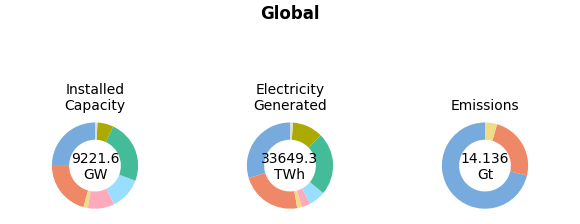

Saved Developed Countries visualization to energy_mix_donut_charts/energy_mix_developed_countries.png


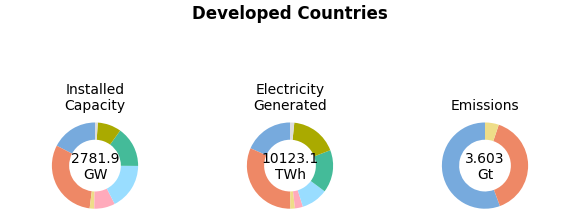

Saved Developing Countries visualization to energy_mix_donut_charts/energy_mix_developing_countries.png


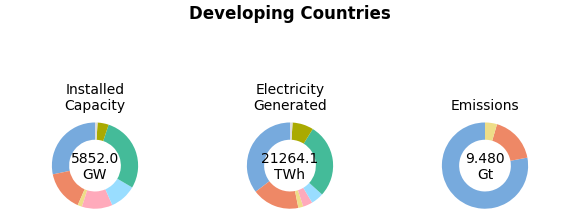

Saved India visualization to energy_mix_donut_charts/energy_mix_india.png


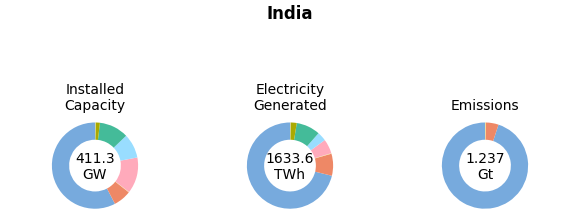

Saved Indonesia visualization to energy_mix_donut_charts/energy_mix_indonesia.png


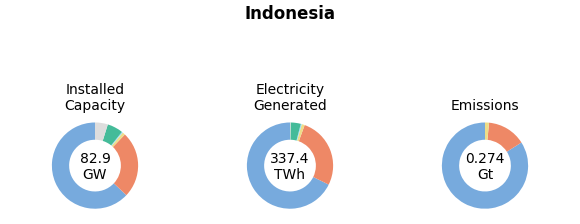

Saved South Africa visualization to energy_mix_donut_charts/energy_mix_south_africa.png


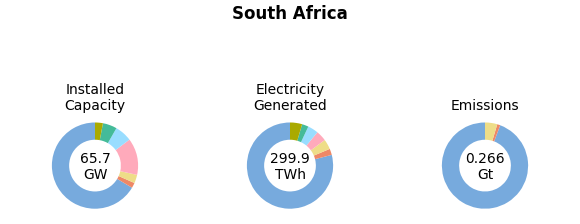

Saved Mexico visualization to energy_mix_donut_charts/energy_mix_mexico.png


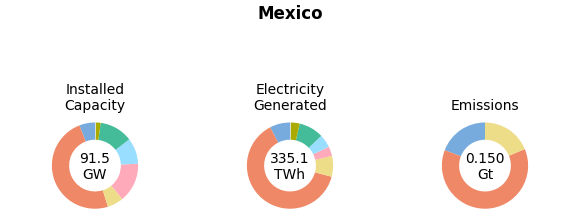

Saved Vietnam visualization to energy_mix_donut_charts/energy_mix_vietnam.png


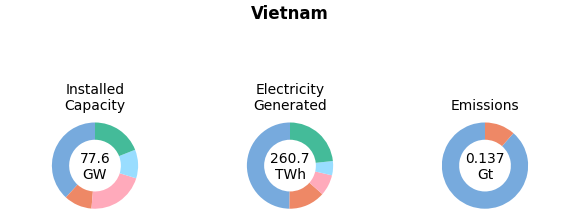

Saved Iran visualization to energy_mix_donut_charts/energy_mix_iran.png


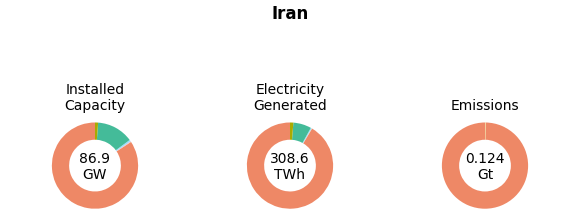

Saved Thailand visualization to energy_mix_donut_charts/energy_mix_thailand.png


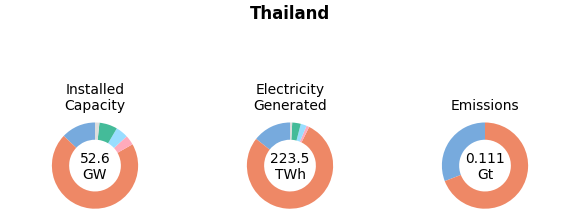

Saved Egypt visualization to energy_mix_donut_charts/energy_mix_egypt.png


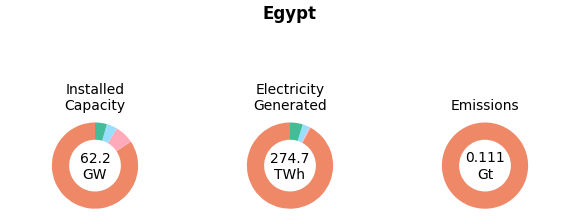

All visualizations completed and saved.


In [24]:
if __name__ == "__main__":
    main()